# Método de Newton-Raphson

## Ideia do método

Desejamos encontrar uma aproximação $\bar{x}$ para a raiz $\xi$ da equação

$$
f(x)=0
$$

A partir de uma aproximação inicial $x_0$, construímos a reta tangente à curva em $(x_k,f(x_k))$.

A interseção dessa reta com o eixo $x$ fornece a próxima aproximação.

$$
x_{k+1}=x_k-\frac{f(x_k)}{f'(x_k)}
$$

O processo é repetido até atingir a precisão desejada.

## Algoritmo

```text
Entrada:
    aproximação inicial x
    precisões ε₁ e ε₂
    número máximo de iterações K

k = 0

enquanto (k < K)

    x_novo = x − f(x)/f'(x)

    se |f(x_novo)| < ε₁
        retorne x_novo

    se |x_novo − x| < ε₂
        retorne x_novo

    x = x_novo
    k = k + 1

retorne x
```

In [1]:
import math

def newton(f, df, x0, eps1=1e-3, eps2=1e-3, kmax=100):
    x = x0
    k = 0

    while k < kmax:
        x_novo = x - f(x)/df(x)

        if abs(f(x_novo)) < eps1:
            return x_novo, k+1

        if abs(x_novo-x) < eps2:
            return x_novo, k+1

        x = x_novo
        k += 1

    return x, k


## Exemplo 1

$$
f(x)=x^2+x-6,
\qquad x_0=1.5,
\qquad \varepsilon_1=\varepsilon_2=10^{-4}.
$$

In [2]:
f=lambda x:x**2+x-6
df=lambda x:2*x+1

newton(f,df,1.5,1e-4,1e-4)

(2.000000116152868, 3)

## Exemplo 2

$$
f(x)=x^3-9x+3,
\qquad x_0=1.5,
\qquad \varepsilon_1=\varepsilon_2=10^{-4}.
$$

In [3]:
f=lambda x:x**3-9*x+3
df=lambda x:3*x**2-9

newton(f,df,1.5,1e-4,1e-4)

(2.816914052872279, 11)

## Exercício

$$
f(x)=x^2-5,
\qquad x_0=2,
\qquad \varepsilon_1=\varepsilon_2=10^{-4}.
$$

In [4]:
f=lambda x:x**2-5
df=lambda x:2*x

newton(f,df,2,1e-4,1e-4)

(2.236067977915804, 3)

## Análise da Convergência

A seguir registramos o histórico das iterações para construir tabelas e visualizar a convergência do método.

In [5]:
def newton_historico(f,df,x0,eps1=1e-3,eps2=1e-3,kmax=100):
    ks=[]
    X=[]
    FX=[]
    DX=[]

    x=x0

    for k in range(1,kmax+1):
        xn=x-f(x)/df(x)

        ks.append(k)
        X.append(xn)
        FX.append(f(xn))
        DX.append(abs(xn-x))

        if abs(f(xn))<eps1 or abs(xn-x)<eps2:
            break

        x=xn

    return ks,X,FX,DX

In [6]:
import pandas as pd

f=lambda x:x**2-5
df=lambda x:2*x

k,x,fx,dx=newton_historico(f,df,2,eps1=1e-4,eps2=1e-4)

tabela=pd.DataFrame({
    "k":k,
    "x":x,
    "f(x)":fx,
    "|Delta_x|":dx
})

tabela

,k,x,f(x),|Delta_x|
0,1,2.250000,6.250000e-02,0.250000
1,2,2.236111,1.929012e-04,0.013889
2,3,2.236068,1.860474e-09,0.000043


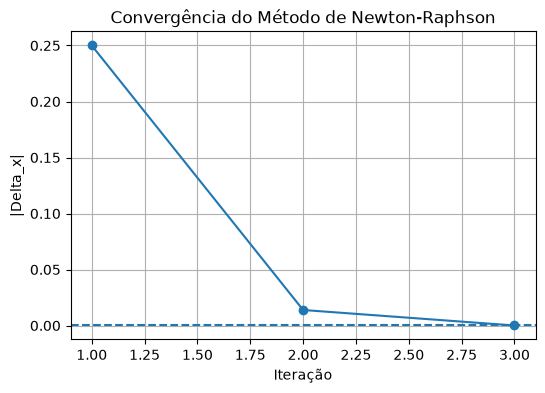

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(tabela["k"],tabela["|Delta_x|"],marker="o")
plt.axhline(1e-4,linestyle="--")
plt.xlabel("Iteração")
plt.ylabel("|Delta_x|")
plt.title("Convergência do Método de Newton-Raphson")
plt.grid(True)
plt.show()